<a href="https://colab.research.google.com/github/wjarret/Thesis_Code_Book/blob/main/snRNA%20data%20analysis/Aim%201/PCA_Hierarchical_Clustering_snRNA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Overview

Scientific question: Can we determine groupings and separations of snRNA based on their nucleotides?

Samples: All U snRNA sequencing data to date.

Experimental design: Perform dimensionality reduction using Principal Component Analysis and Hierarchical Clustering.

Expected outcome: This experiment will separate all U snRNA along different PCs, showing us similar groupings based around biological function (homologs) and structure.

Steps:

> 1. Load in all datasets
>
> 2. Splice out desired nucleotide window frame
>
> 3. Run Principal Component Analysis (PCA) on all data and define inclusive principal components for Hierarchical Clustering
>
> 4. Analyze output with respect to biological significance

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from google.colab import data_table
data_table.enable_dataframe_formatter()
!pip install itables
import itables
from itables import init_notebook_mode
init_notebook_mode()
from matplotlib import pyplot as plt
import seaborn as sns
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# path = "/Users/jarrettscomputer/University of Michigan Dropbox/MED-RNA-Lab/Team Members/Wjarret/Lab Notebook/General Data/RNP-MaP Results/Dada2_denoising_URNA_03082026/RNP_MaP_CSVs"
path = "/content/drive/My Drive/Data/RNP_MaP_CSVs"

# To access files in Colab, you generally need to mount Google Drive or upload files.
# Example for mounting Google Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# path = '/content/drive/My Drive/Your_Folder/RNP_MaP_CSVs'

# Please update the 'path' variable to the correct location of your files in Colab's file system.
# For now, I'm commenting out the lines that caused the FileNotFoundError.
os.chdir(path)
dir_list = os.listdir(path)
dir_list


['HeLa-U1_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv',
 'HeLa-U5_DMSO_aq_SDA_int_20260129_U5B_profile_RESULTS.csv',
 'HeLa-U5_DMSO_aq_SDA_int_20260129_U5A_profile_RESULTS.csv',
 'HeLa-U4atac_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv',
 'HeLa-U4_DMSO_aq_SDA_int_20260129_U4-2_profile_RESULTS.csv',
 'HeLa-U4_DMSO_aq_SDA_int_20260129_U4-1_profile_RESULTS.csv',
 'HeLa-U12_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv',
 'HeLa-U11_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv',
 'HeLa-U1_DMSO_aq_SDA_int_11092024_ASV1_profile_RESULTS.csv',
 'HeLa-U2_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv',
 'HeLa-U11_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv',
 'HeLa-U12_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv',
 'HeLa-U1_DMSO_aq_SDA_int_20250525_ASV1_profile_RESULTS.csv',
 'HeLa-U1_DMSO_aq_SDA_int_20250707_ASV2_profile_RESULTS.csv',
 'HeLa-U11_DMSO_aq_SDA_int_20250707_ASV1_profile_RESULTS.csv',
 'HeLa-U12_DMSO_aq_SDA_int_20250707_ASV1_profile_RESULTS.csv',
 'HeLa

### Loading in the DataFrame

In [ ]:
#20260129
U1_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U1_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv')
U11_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U11_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv')
U12_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U12_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv')
U4_1_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U4_DMSO_aq_SDA_int_20260129_U4-1_profile_RESULTS.csv')
U4_2_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U4_DMSO_aq_SDA_int_20260129_U4-2_profile_RESULTS.csv')
U4_atac_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U4atac_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv')
U5A_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U5_DMSO_aq_SDA_int_20260129_U5A_profile_RESULTS.csv')
U5B_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U5_DMSO_aq_SDA_int_20260129_U5B_profile_RESULTS.csv')
#07/07/2025
U1_DMSO_aq_SDA_int_20250707 = pd.read_csv('HeLa-U1_DMSO_aq_SDA_int_20250707_ASV2_profile_RESULTS.csv')
U2_DMSO_aq_SDA_int_20250707 = pd.read_csv('HeLa-U2_DMSO_aq_SDA_int_20250707_ASV1_profile_RESULTS.csv')
U11_DMSO_aq_SDA_int_20250707 = pd.read_csv('HeLa-U11_DMSO_aq_SDA_int_20250707_ASV1_profile_RESULTS.csv')
U12_DMSO_aq_SDA_int_20250707 = pd.read_csv('HeLa-U12_DMSO_aq_SDA_int_20250707_ASV1_profile_RESULTS.csv')
#05/05/2025
U1_DMSO_aq_SDA_int_20250525 = pd.read_csv('HeLa-U1_DMSO_aq_SDA_int_20250525_ASV1_profile_RESULTS.csv')
#11/09/24
U1_DMSO_aq_SDA_int_11092024 = pd.read_csv('HeLa-U1_DMSO_aq_SDA_int_11092024_ASV1_profile_RESULTS.csv')
U2_DMSO_aq_SDA_int_11092024 = pd.read_csv('HeLa-U2_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv')
U11_DMSO_aq_SDA_int_11092024 = pd.read_csv('HeLa-U11_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv')
U12_DMSO_aq_SDA_int_11092024 = pd.read_csv('HeLa-U12_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv')


### Filtering the Sm Seqeunces

In [ ]:
#slicing norm score
#U1
Filtered_U1_11092024 = U1_DMSO_aq_SDA_int_11092024[['Norm_Score']].iloc[118:142]
Filtered_U1_20250525 = U1_DMSO_aq_SDA_int_20250525[['Norm_Score']].iloc[118:142]
Filtered_U1_20250707 = U1_DMSO_aq_SDA_int_20250707[['Norm_Score']].iloc[118:142]
Filtered_U1_20260129 = U1_DMSO_aq_SDA_int_20260129[['Norm_Score']].iloc[114:138]

#U2
Filtered_U2_11092024 = U2_DMSO_aq_SDA_int_11092024[['Norm_Score']].iloc[90:114]
Filtered_U2_20250707 = U2_DMSO_aq_SDA_int_20250707[['Norm_Score']].iloc[90:114]

#U11
Filtered_U11_11092024 = U11_DMSO_aq_SDA_int_11092024[['Norm_Score']].iloc[80:104]
Filtered_U11_20250707 = U11_DMSO_aq_SDA_int_20250707[['Norm_Score']].iloc[80:104]
Filtered_U11_20260129 = U11_DMSO_aq_SDA_int_20260129[['Norm_Score']].iloc[78:102]

#U12
Filtered_U12_11092024 = U12_DMSO_aq_SDA_int_11092024[['Norm_Score']].iloc[66:90]
Filtered_U12_20250707 = U12_DMSO_aq_SDA_int_20250707[['Norm_Score']].iloc[66:90]
Filtered_U12_20260129 = U12_DMSO_aq_SDA_int_20260129[['Norm_Score']].iloc[64:88]

#U4
Filtered_U4_1_20260129   = U4_1_DMSO_aq_SDA_int_20260129[['Norm_Score']].iloc[110:134]
Filtered_U4_2_20260129   = U4_2_DMSO_aq_SDA_int_20260129[['Norm_Score']].iloc[110:134]
Filtered_U4_atac_20260129 = U4_atac_DMSO_aq_SDA_int_20260129[['Norm_Score']].iloc[97:121]

#U5
Filtered_U5A_20260129 = U5A_DMSO_aq_SDA_int_20260129[['Norm_Score']].iloc[80:104]
Filtered_U5B_20260129 = U5B_DMSO_aq_SDA_int_20260129[['Norm_Score']].iloc[80:104]

#making a dicionary of the filtered dataframes for PCA
PCA_Matrix = {
    'U1.1':  Filtered_U1_11092024.values.flatten(),
    'U1.2':  Filtered_U1_20250525.values.flatten(),
    'U1.3':  Filtered_U1_20250707.values.flatten(),
    'U1.4':  Filtered_U1_20260129.values.flatten(),
    'U2.1':  Filtered_U2_11092024.values.flatten(),
    'U2.2':  Filtered_U2_20250707.values.flatten(),
    'U11.1': Filtered_U11_11092024.values.flatten(),
    'U11.2': Filtered_U11_20250707.values.flatten(),
    'U11.3': Filtered_U11_20260129.values.flatten(),
    'U12.1': Filtered_U12_11092024.values.flatten(),
   #'U12.2': Filtered_U12_20250707.values.flatten(),
    'U12.3': Filtered_U12_20260129.values.flatten(),
    'U4-1': Filtered_U4_1_20260129.values.flatten(),
    'U4-2': Filtered_U4_2_20260129.values.flatten(),
    'U4atac': Filtered_U4_atac_20260129.values.flatten(),
    'U5A': Filtered_U5A_20260129.values.flatten(),
    'U5B': Filtered_U5B_20260129.values.flatten()
}

### Dimensionality Reduction

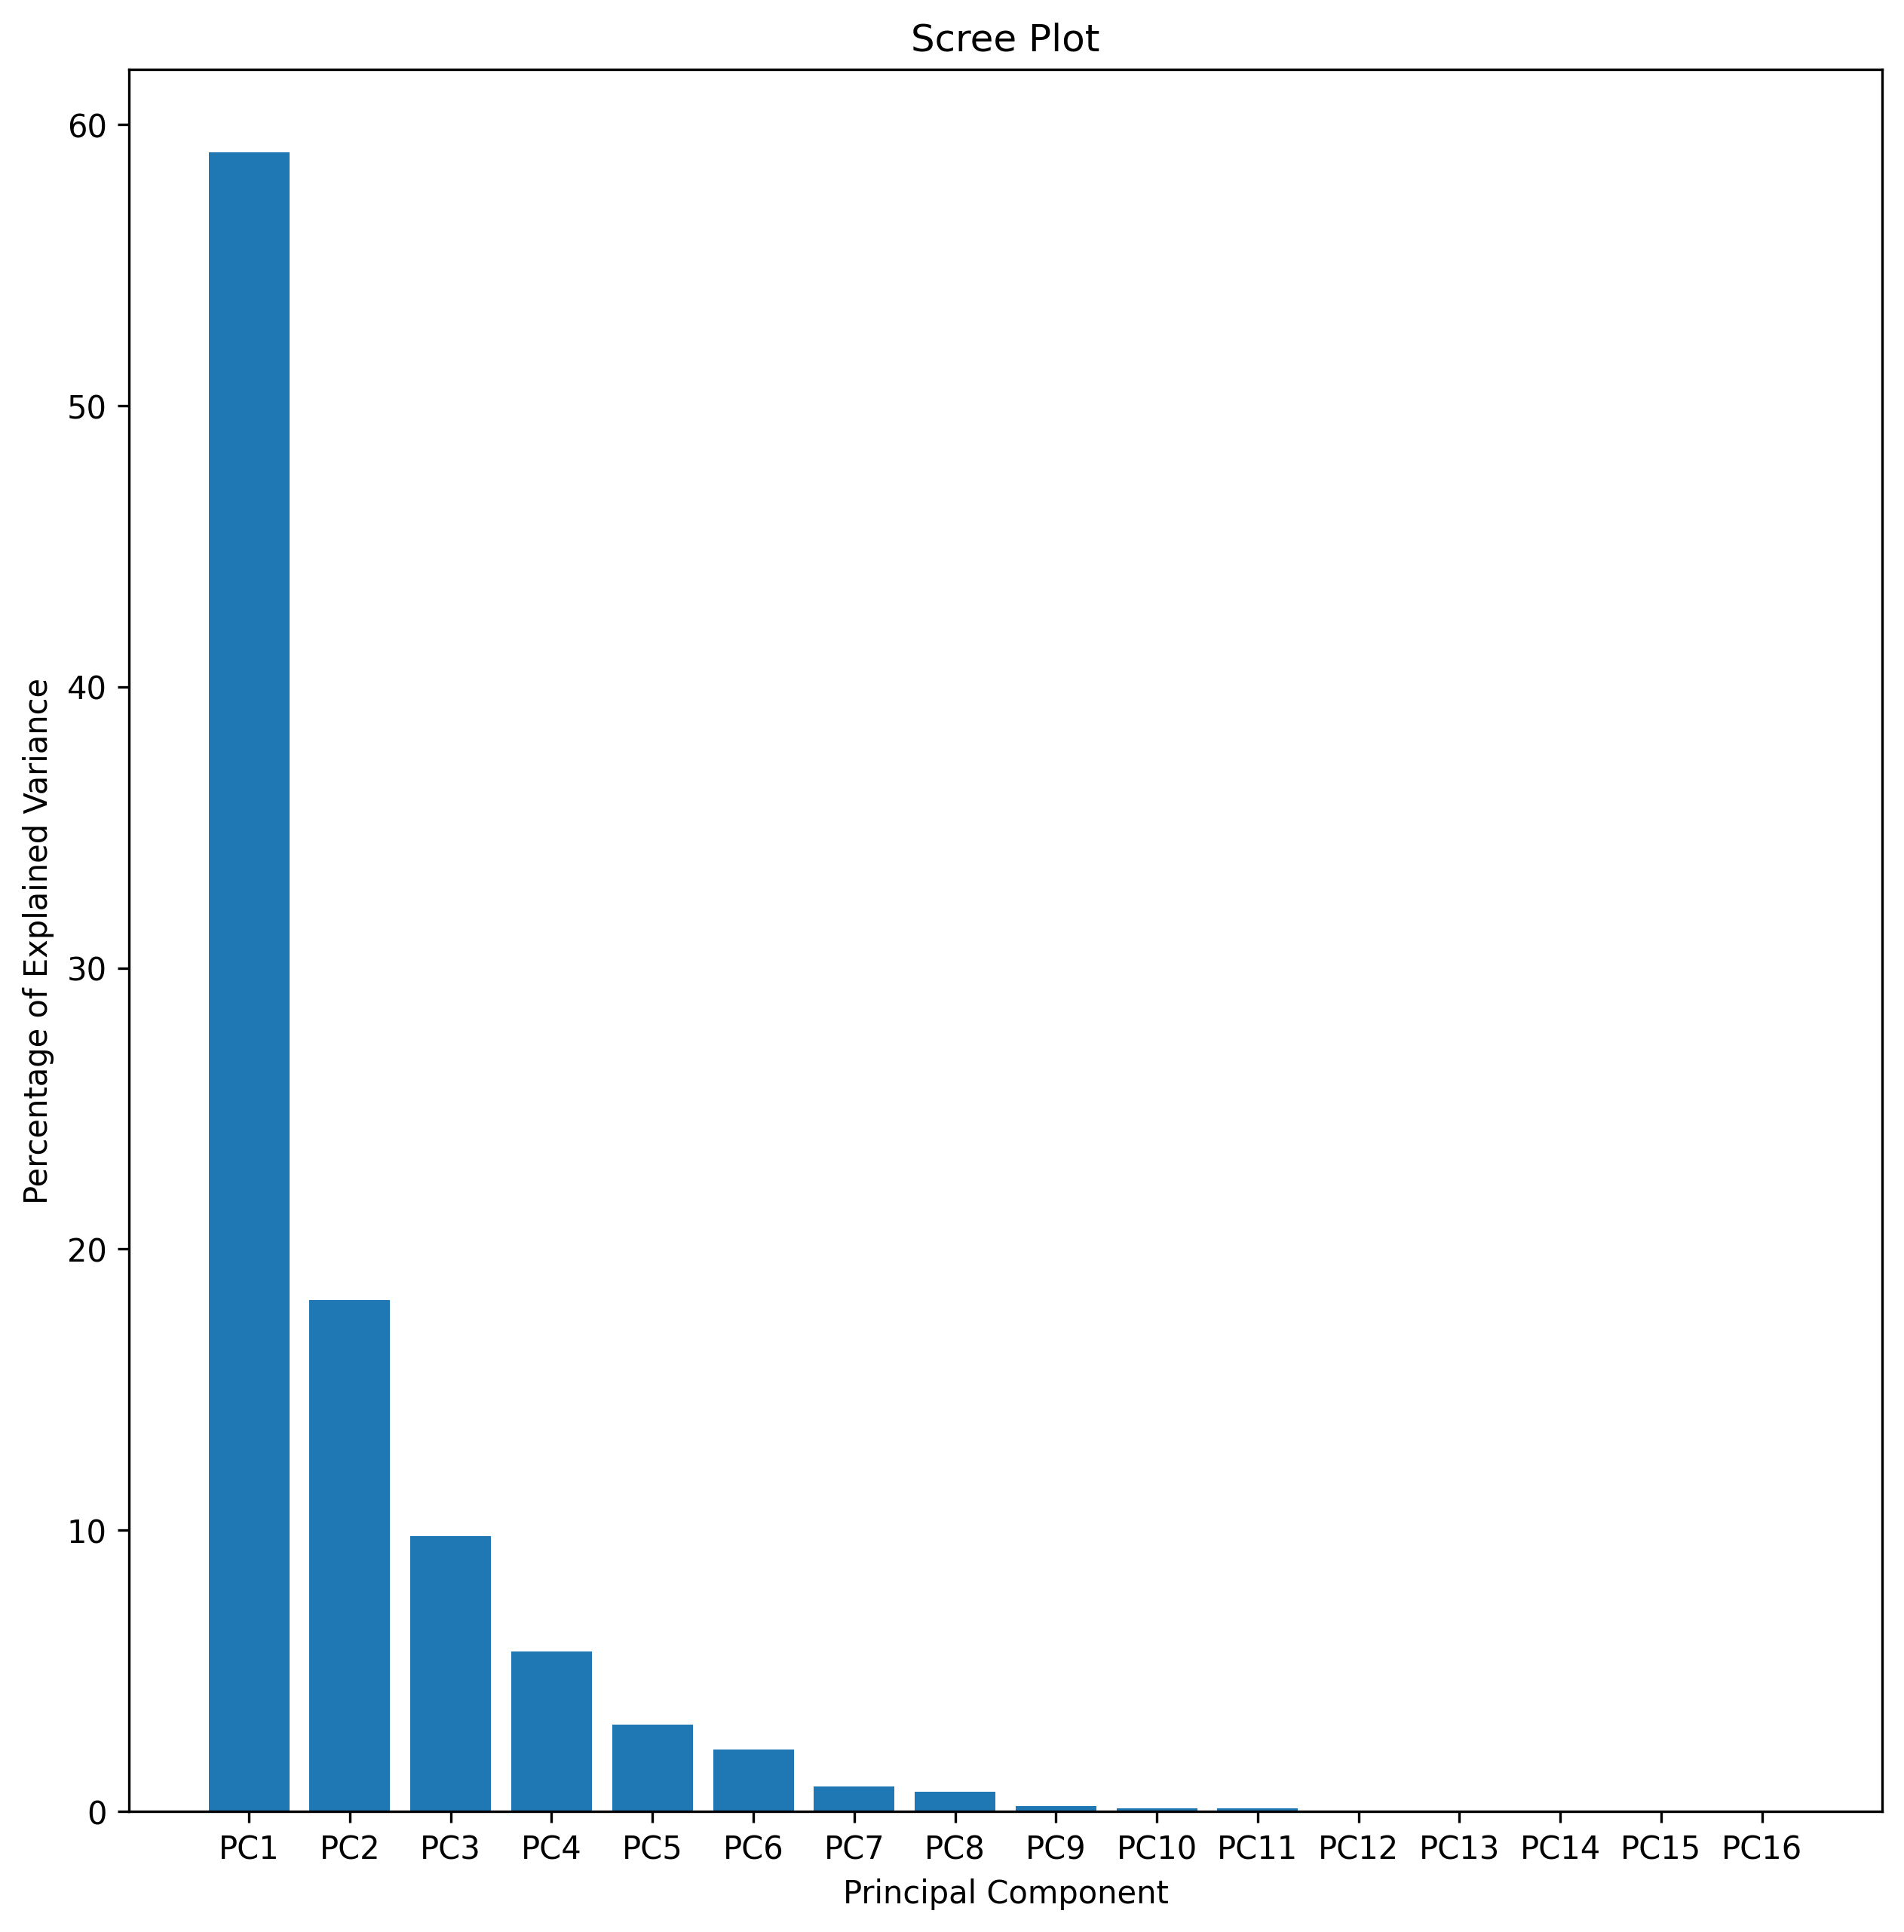

In [ ]:
from scipy.stats import spearmanr

#PCA on Spearman correlation Matrix
#This step was added due to the non-normality of the data

spearman_corr_matrix = pp.corr(method='spearman').fillna(0)
scaler = StandardScaler()
scaled_corr_matrix = scaler.fit_transform(spearman_corr_matrix)
pca = PCA()
pca_scores = pca.fit_transform(scaled_corr_matrix)

per_var = np.round(pca.explained_variance_ratio_ * 100, decimals=1)
labels = ['PC' + str(x) for x in range(1, len(per_var) + 1)]

plt.figure(figsize=(10, 10), dpi=300)
plt.bar(x=range(1, len(per_var) + 1), height=per_var, tick_label=labels)
plt.ylabel('Percentage of Explained Variance')
plt.xlabel('Principal Component')
plt.title('Scree Plot')
plt.show()

#PCA on Raw, normalized data
# pp = pd.DataFrame(PCA_Matrix)
# pca_matrix = pp.T.fillna(0)
# # Log transform (using log1p to handle zeros: log(x + 1))
# log_pca_matrix = np.log1p(pca_matrix)

# # Now check normality on the transformed data
# from scipy.stats import shapiro
# for col in log_pca_matrix.columns:
#     stat, p = shapiro(log_pca_matrix[col])
#     print(f'{col}: p={p:.4f}')

# # Run PCA on log-transformed data
# scaler = StandardScaler(with_mean=True, with_std=True)
# scaled_data = scaler.fit_transform(log_pca_matrix)
# pca = PCA()
# pca.fit(scaled_data)
# pca_scores = pca.transform(scaled_data)
# per_var = np.round(pca.explained_variance_ratio_ * 100, decimals=1)
# labels = ['PC' + str(x) for x in range(1, len(per_var) + 1)]

# plt.figure(figsize=(10, 10), dpi=300)
# plt.bar(x=range(1, len(per_var) + 1), height=per_var, tick_label=labels)
# plt.ylabel('Percentage of Explained Variance')
# plt.xlabel('Principal Component')
# plt.title('Scree Plot')
# plt.show()

## Change from original PCA to Analysis of Ranks

PCA was computed on a Spearman correlation matrix instead of a Pearson-based covariance to account for the non-normal distribution of Norm_Score values and reduce the influence of outliers on the resulting principal components.

Text(0, 0.5, 'Cumulative Explained Variance')

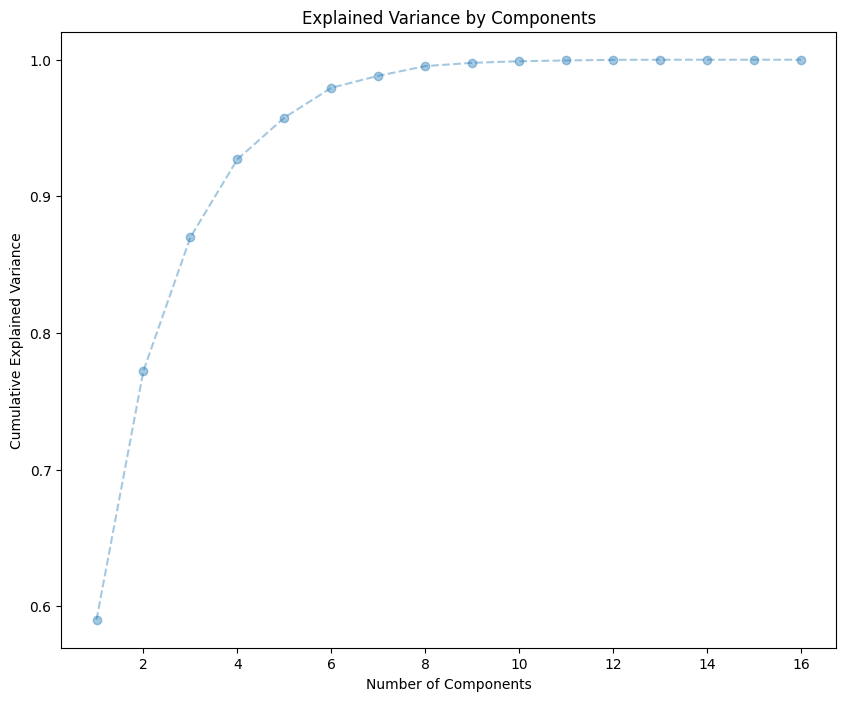

In [ ]:
plt.figure( figsize = (10,8))
plt.plot(range(1,len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_.cumsum(), marker = 'o', linestyle = '--', alpha=0.4)
plt.title("Explained Variance by Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

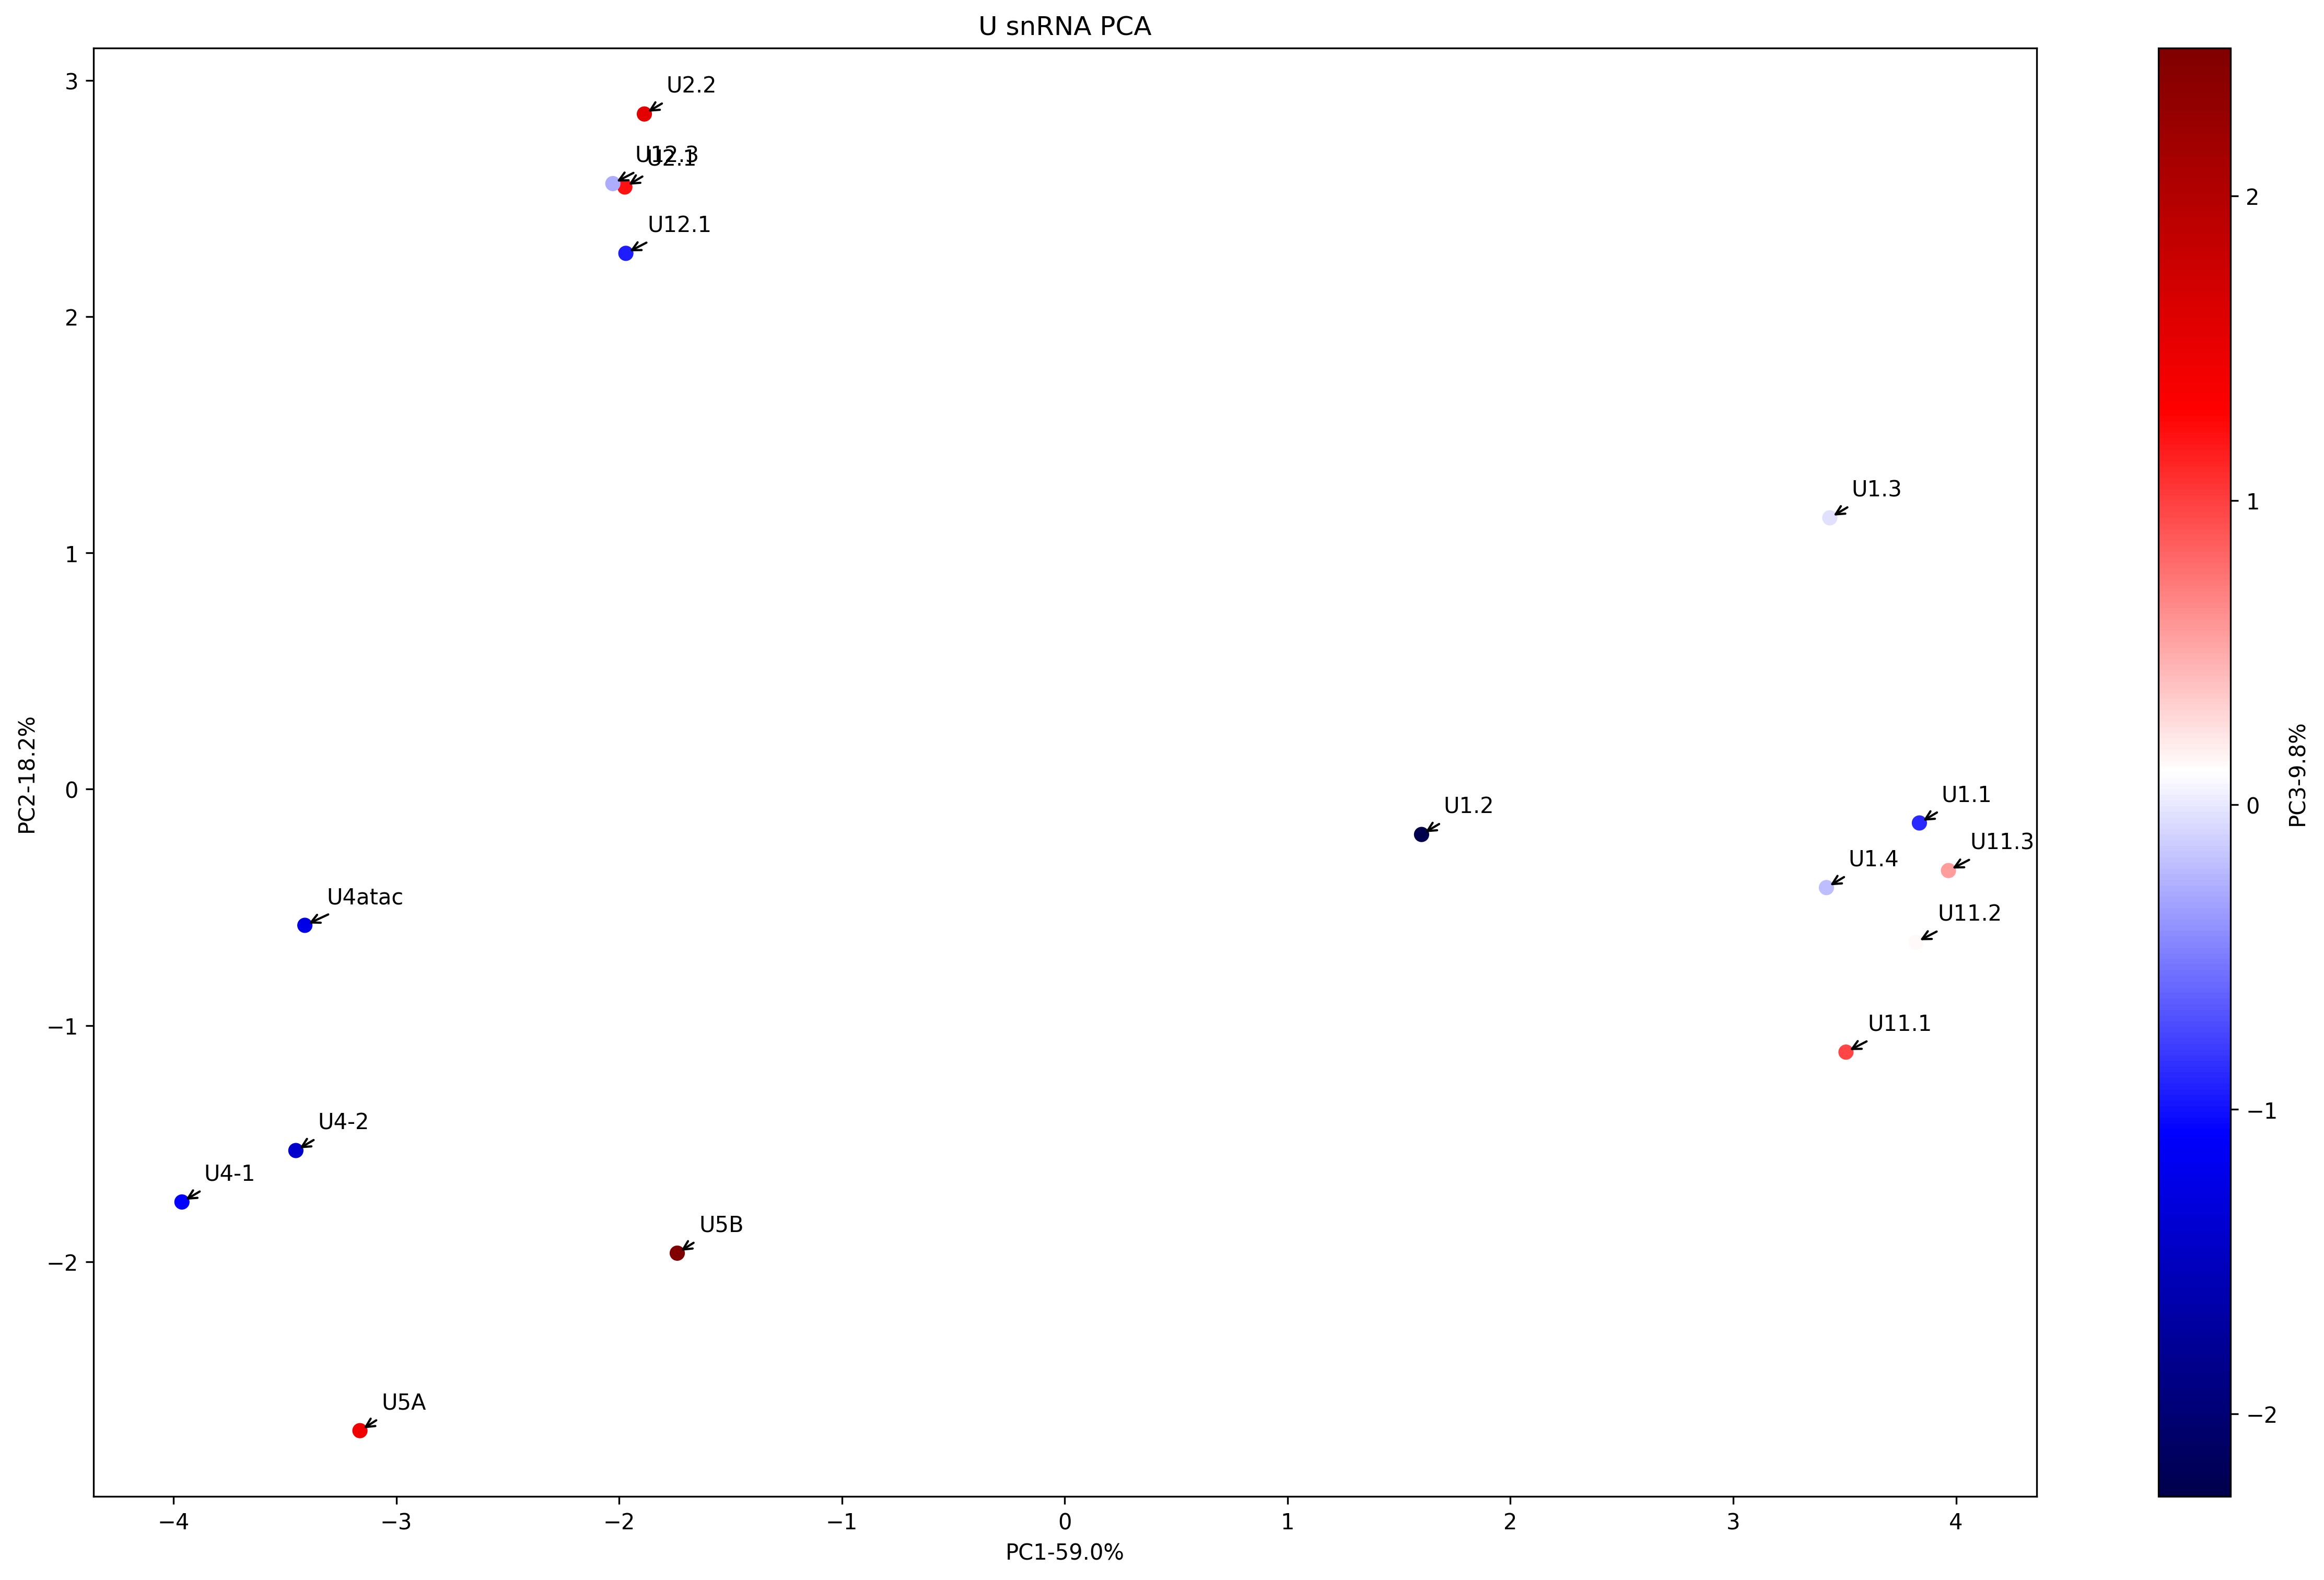

In [ ]:
#labels = ['U1_11092024', 'U1_20250707', 'U1_20260129', 'U2_11092024', 'U2_20250707',
        #   'U11_11092024', 'U11_20250707', 'U11_20260129', 'U12_11092024', 'U12_20250707',
        #   'U12_20260129', 'U4_1_20260129', 'U4_2_20260129', 'U4_atac_20260129',
        #   'U5A_20260129', 'U5B_20260129']
#show(pca_df)
pca_df = pd.DataFrame(pca_scores, index=pp.columns,
                      columns=[f'PC{i+1}' for i in range(pca_scores.shape[1])])
#pca_df = pd.DataFrame(pca_data, columns=labels)
#show(pca_df)
plt.figure(figsize=(20, 12), dpi=300)

plt.title('U snRNA PCA')

scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['PC3'], cmap= 'seismic')
plt.xlabel('PC1-{0}%'.format(per_var[0]))
plt.ylabel('PC2-{0}%'.format(per_var[1]))
plt.colorbar(scatter, label='PC3-{0}%'.format(per_var[2]))

for sample in pca_df.index:
    plt.annotate(sample, (pca_df['PC1'][sample], pca_df['PC2'][sample]), xytext=(10, 10),
             textcoords='offset points',
             arrowprops=dict(arrowstyle='->'))
# plt.savefig('snRNA_PCA_03162026.png', dpi=300)
plt.show()

In [ ]:
# loading_scores = pd.Series(pca.components_[0], index=pca_matrix.index)
# sorted_loading_scores = loading_scores.abs().sort_values(ascending=False)
# print(sorted_loading_scores)

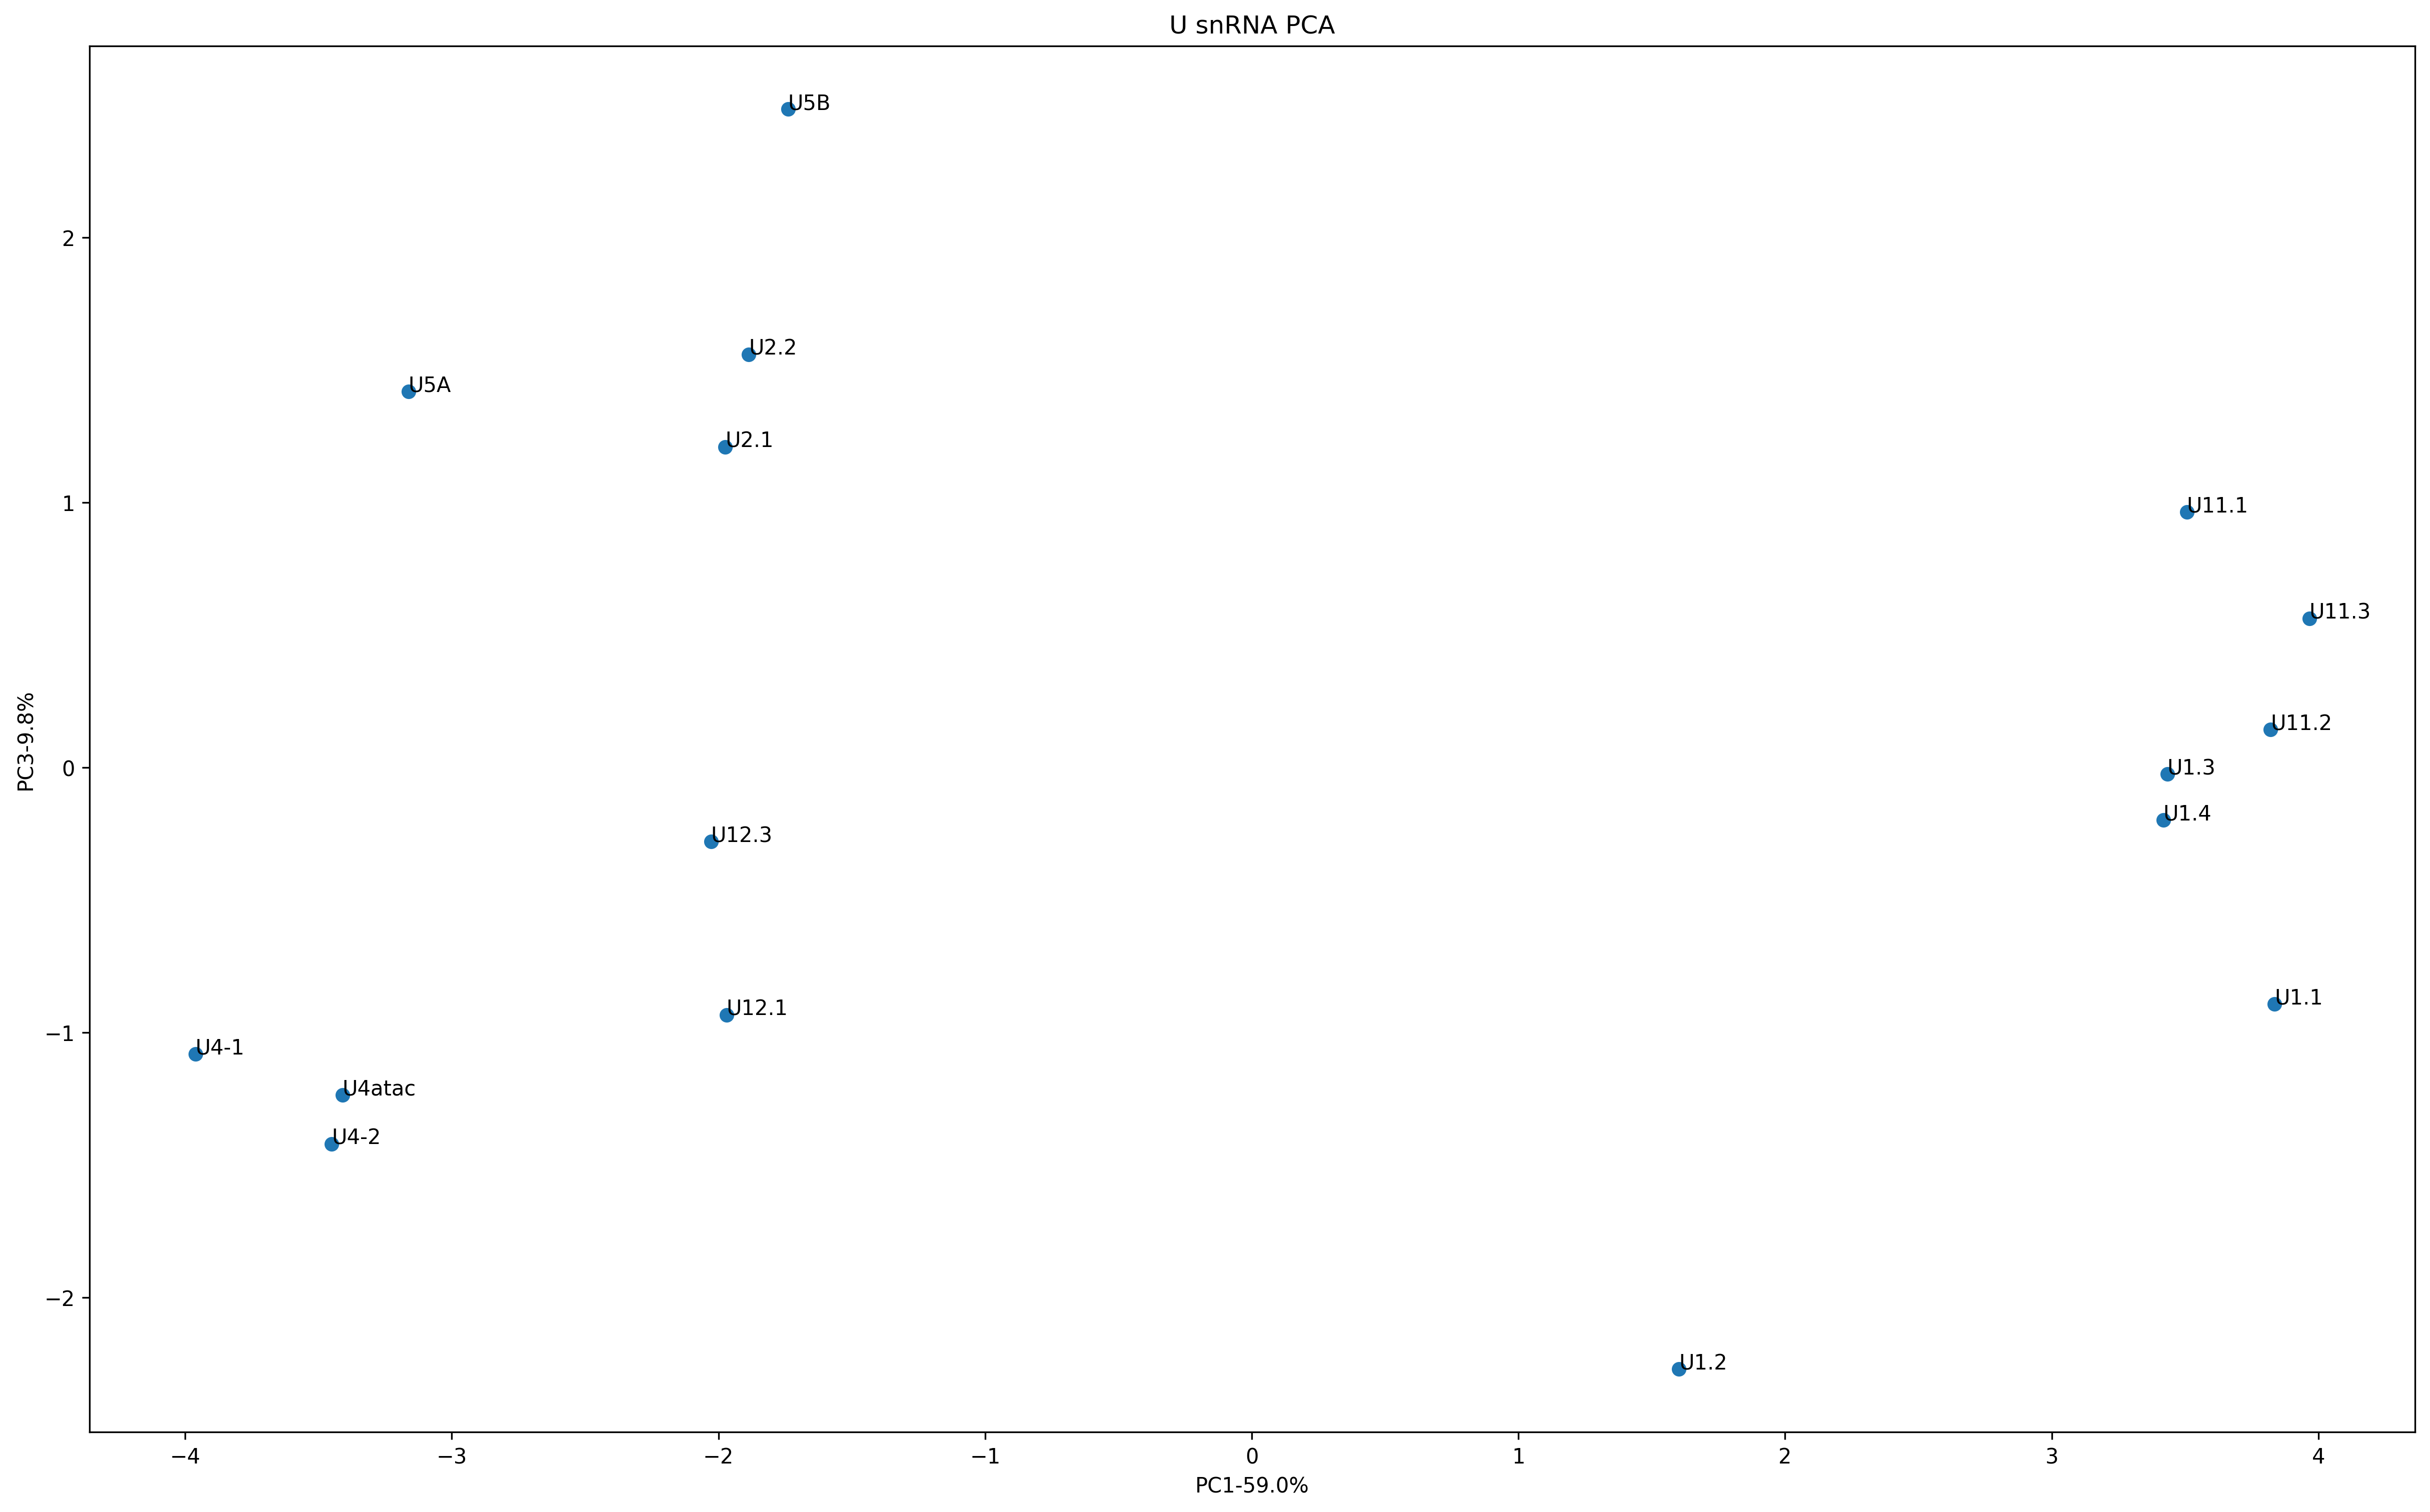

In [ ]:
plt.figure(figsize=(20, 12), dpi=300)

plt.scatter(pca_df['PC1'], pca_df['PC3'])
plt.title('U snRNA PCA')
plt.xlabel('PC1-{0}%'.format(per_var[0]))
plt.ylabel('PC3-{0}%'.format(per_var[2]))
for sample in pca_df.index:
    plt.annotate(sample, (pca_df['PC1'][sample], pca_df['PC3'][sample]))
# plt.savefig('snRNA_PC1_3_03162026.png', dpi=300)
plt.show()




> U11 replicates show greater variability than other snRNAs, particularly along PC3. U12 replicates also show some spread, though less extreme. Given that samples were collected across multiple dates, whether this variation reflects batch effects or true biological differences in RNP-MaP reactivity profiles warrants further investigation.

In [ ]:
#3D
import plotly.express as px
labels = ['U1_11092024', 'U1_20250525', 'U1_20250707', 'U1_20260129', 'U2_11092024', 'U2_20250707',
          'U11_11092024', 'U11_20250707', 'U11_20260129', 'U12_11092024',
          'U12_20260129', 'U4_1_20260129', 'U4_2_20260129', 'U4_atac_20260129',
          'U5A_20260129', 'U5B_20260129']
pca_df = pd.DataFrame(pca_scores, index=pp.columns,
                      columns=[f'PC{i+1}' for i in range(pca_scores.shape[1])])
pca_df['label'] = labels
# print(pca_df)
#pca_df = pd.DataFrame(pca_data, columns=labels)
#show(pca_df)

# fig = plt.figure(figsize=(20, 12), dpi=300)
# ax = fig.add_subplot(111,projection='3d')
# x = pca_df['PC1']
# y = pca_df['PC2']
# z = pca_df['PC3']
# ax.scatter(x,y,z)
# plt.title('U snRNA PCA')
# ax.set_xlabel('PC1-{0}%'.format(per_var[0]))
# ax.set_ylabel('PC2-{0}%'.format(per_var[1]))
# ax.set_zlabel('PC3-{0}%'.format(per_var[2]))
# for sample in pca_df.index:
#     ax.text(pca_df['PC1'][sample], pca_df['PC2'][sample], pca_df['PC3'][sample], sample)

#plotly express
fig_newton = px.scatter_3d(data_frame=pca_df, x='PC1',y='PC2',z='PC3', hover_data=['label'],
                           labels={'PC1': 'PC1-{0}%'.format(per_var[0]),
                                   'PC2': 'PC2-{0}%'.format(per_var[1]),
                                   'PC3': 'PC3-{0}%'.format(per_var[2])})
fig_newton.show()

To export the Plotly figure as an interactive HTML file, you can use the `fig.write_html()` method. This will save the plot to a specified file path.

In [ ]:
# Export the Plotly figure as an HTML file
output_html_file = 'snRNA_PCA_3D_interactive.html'
fig_newton.write_html(output_html_file)

print(f"Interactive 3D PCA plot saved to {output_html_file}")

Interactive 3D PCA plot saved to snRNA_PCA_3D_interactive.html


In [ ]:
pca_df

Loading ITables v2.7.3 from the internet... (need help?)


### Pairwise Correlation Analysis of Different snRNA

In [ ]:
corr = pca_matrix.T.corr(method = 'spearman')
df_corr = pd.DataFrame(corr).stack()
df_corr


Loading ITables v2.7.3 from the internet... (need help?)


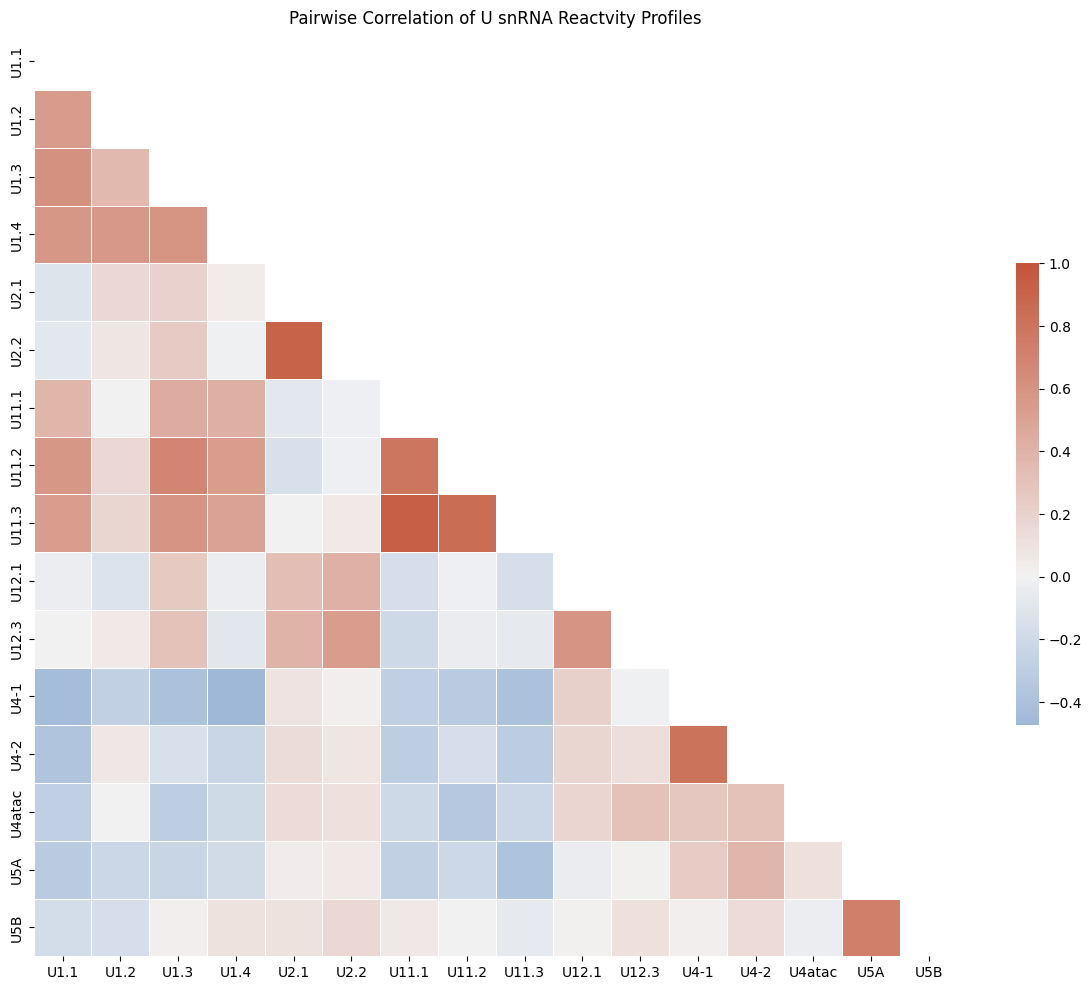

In [ ]:
# mask = np.tril(np.ones_like(corr, dtype=bool))
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(15, 12))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(250, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
Heat = sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, center=0, square=True, linewidths=.5,
            cbar_kws={"shrink": .5}).set(title='Pairwise Correlation of U snRNA Reactvity Profiles')


### Hierarchical Clustering

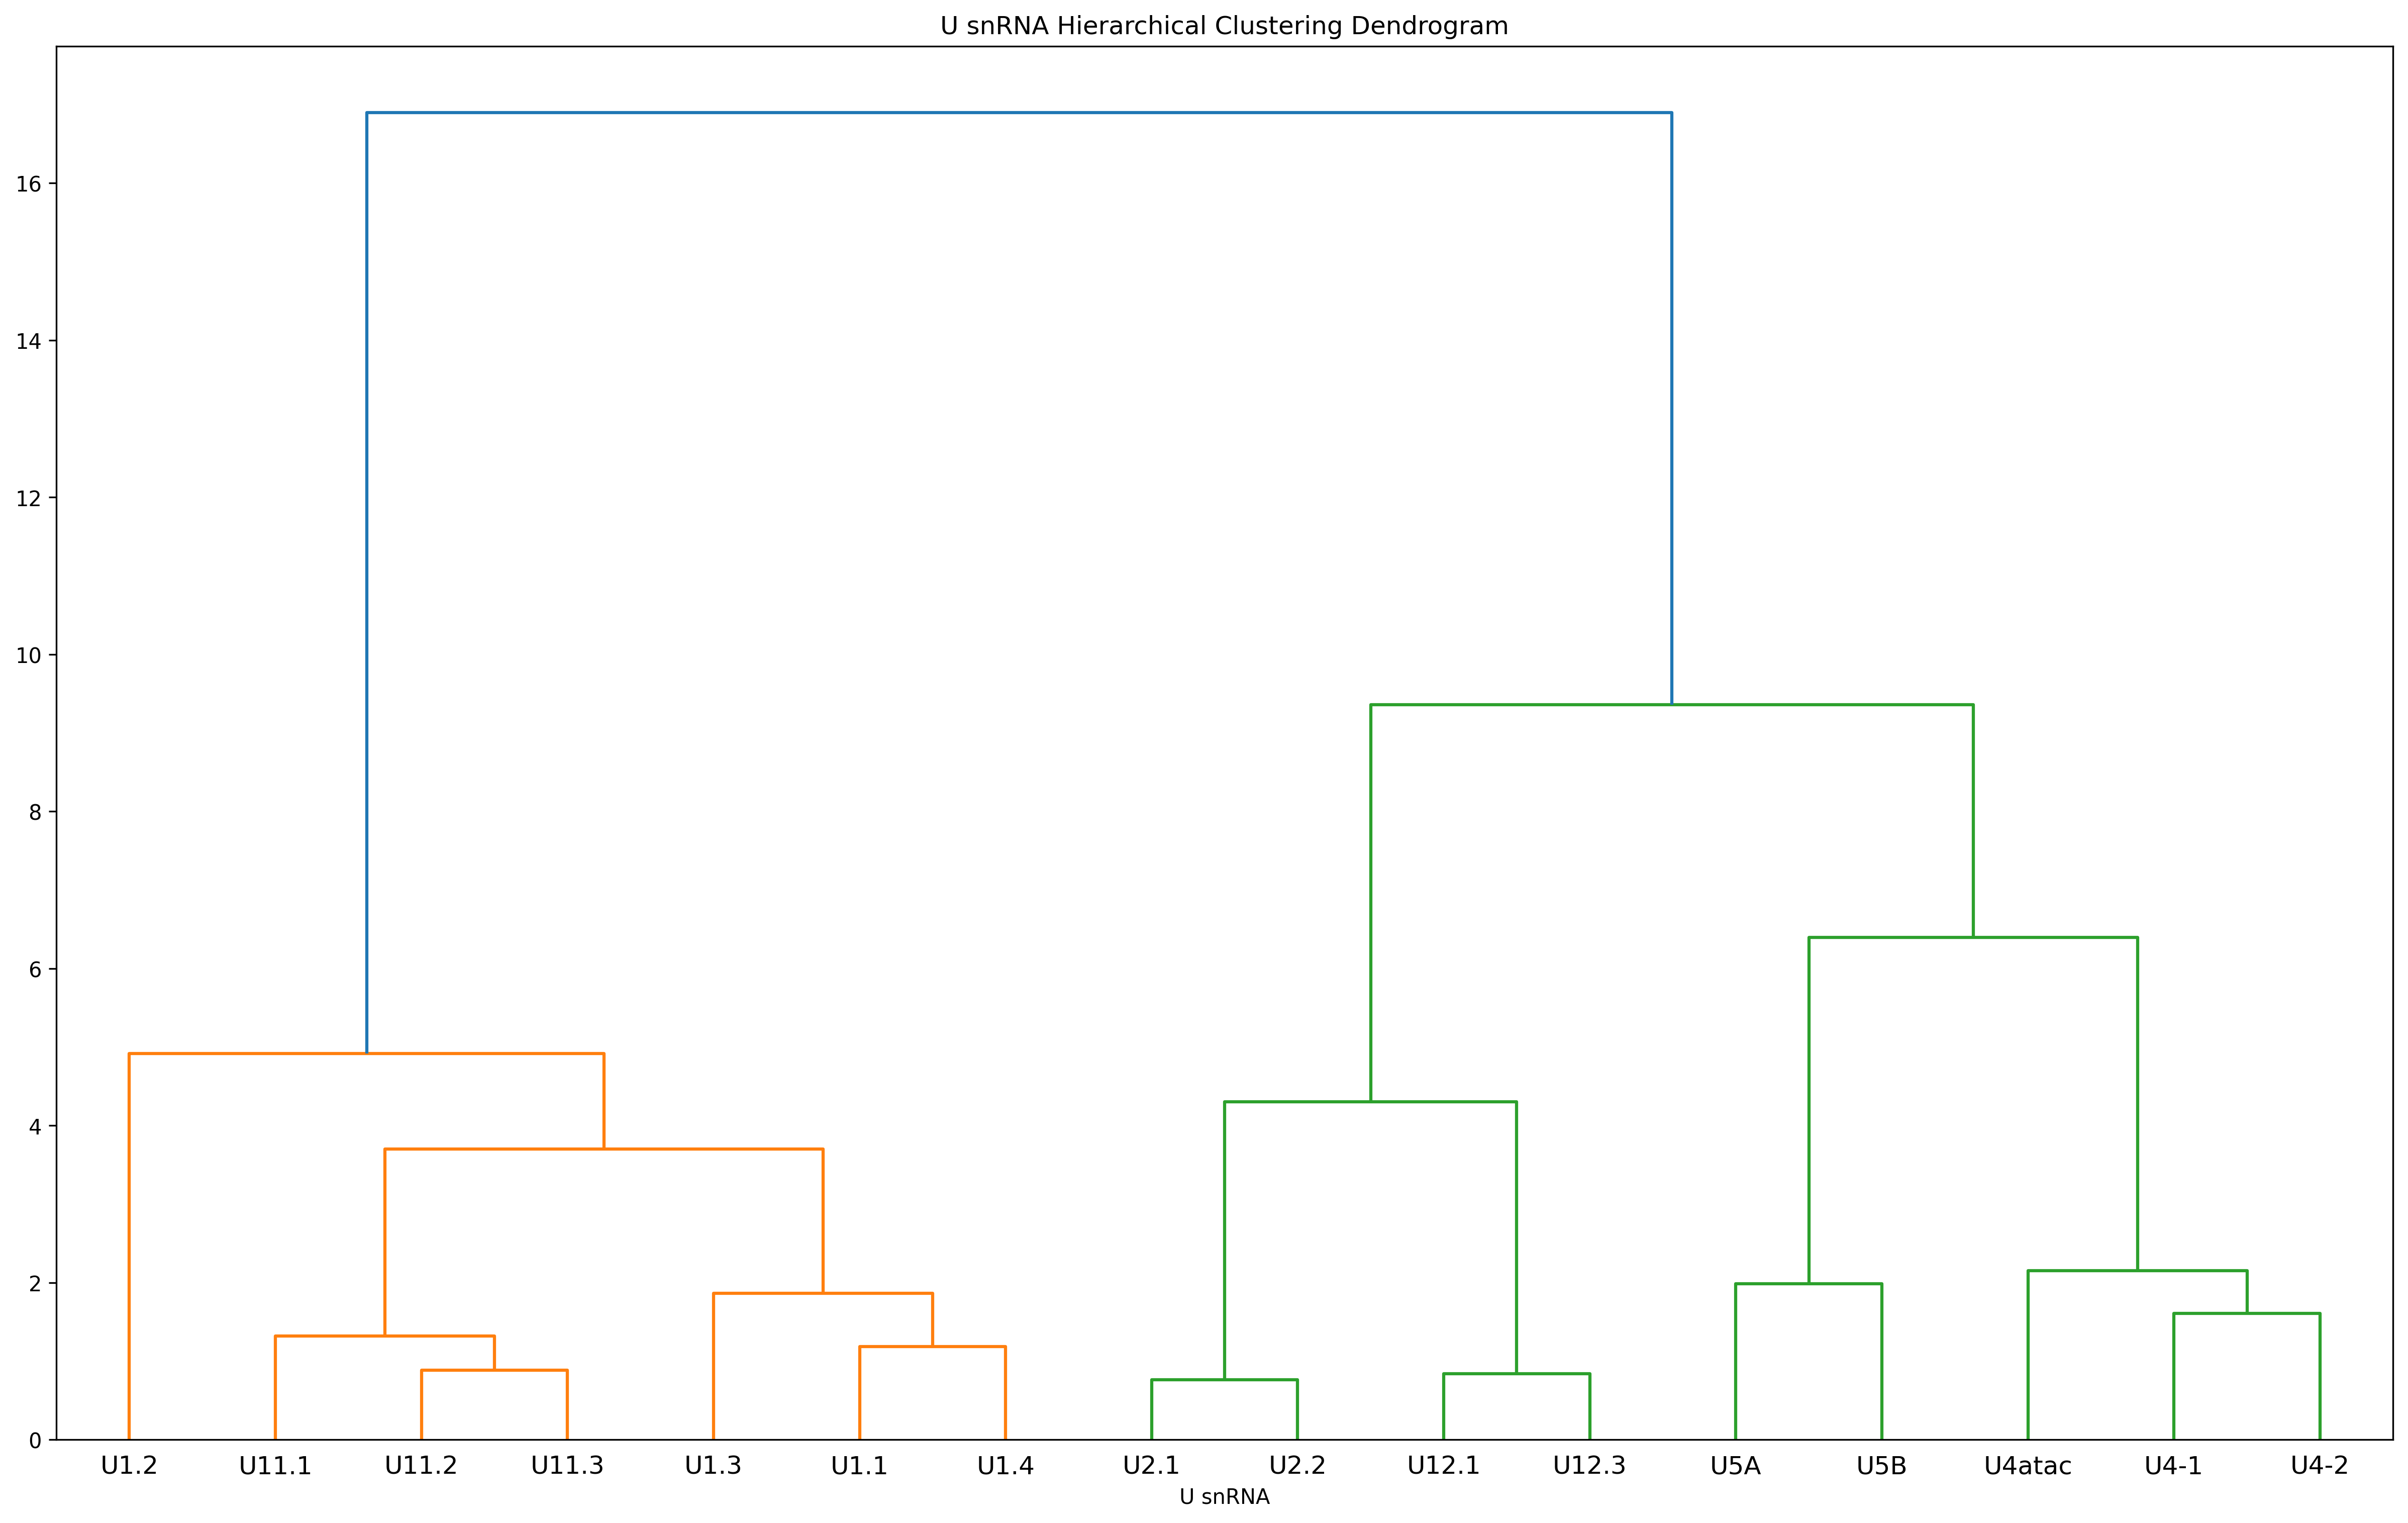

In [ ]:
#import library
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram


def plot_dendrogram(model, X, **kwargs):
    # Create linkage matrix and then plot the dendrogram
    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count
    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)
    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix,labels = X, **kwargs)


# Clustering calculation
# setting distance_threshold=0 ensures we compute the full tree.
H_Clustering = AgglomerativeClustering(n_clusters=None,
                                        distance_threshold=0,
                                        compute_full_tree=True,
                                        linkage = 'ward',
                                        compute_distances= True,)
H_Clustering = H_Clustering.fit(pca_df.iloc[:,:5])
H_Clustering.labels_

plt.figure(figsize=(20,12), dpi = 300)
plt.title("U snRNA Hierarchical Clustering Dendrogram")
plot_dendrogram(H_Clustering, truncate_mode=None,X = pca_df.index)
plt.xlabel("U snRNA")
plt.show()

###**Results**:
>



### **Discussion**

>

###Future Direction
>